# Modulación M-QAM

In [56]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

In [57]:
# Se definen parámetros
Num_intervalos = 5

# Probabilidad de bits
p0 = 0.48
p1 = 1 - p0

# Parámetros de modulación M-QAM
M = 64  # M = μ²
mu = int(np.sqrt(M))  # μ = √M = 2^n
n = int(np.log2(mu))  # bits por componente (I o Q)
n_total = int(np.log2(M))  # bits totales por símbolo = 2n

# Parámetros de símbolo
Ts = 0.001  # Duración del símbolo (2n*Tb)
fs = 1/Ts   # Frecuencia de símbolo

# Parámetros para la gráfica de señales
fmuestreo = 1000000
fc = 10000
Ac = 1

# Número de bits de la secuencia a generar
Num_bits = Num_intervalos * n_total

print(f"M-QAM con M = {M}")
print(f"μ = {mu}")
print(f"n (bits por componente) = {n}")
print(f"Bits totales por símbolo = {n_total}")
print(f"Número de bits a generar = {Num_bits}")

M-QAM con M = 64
μ = 8
n (bits por componente) = 3
Bits totales por símbolo = 6
Número de bits a generar = 30


In [58]:
def generador_secuencia(n, p0, p1, semilla=None):
    # Validación
    if not np.isclose(p0 + p1, 1):
        raise ValueError("Las probabilidades deben cumplir: p0 + p1 = 1")
    rng = np.random.default_rng(semilla)
    return rng.choice([0, 1], size=n, p=[p0, p1])

# Generar secuencia
secuencia = generador_secuencia(Num_bits, p0, p1, semilla=42)

#secuencia=np.array([1,0,1,1,1,0,0,0,0,1,0,1,1,1,1,1])
print(f"Secuencia generada: {secuencia}")

Secuencia generada: [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1]


In [59]:
def gray_code(n):
    """Genera códigos Gray de n bits"""
    if n == 0:
        return ['']
    prev = gray_code(n-1)
    return ['0' + code for code in prev] + ['1' + code for code in reversed(prev)]

## Convertidor de Datos M-QAM

El sistema de conversión de datos para M-QAM consta de dos bloques:

### 1. Convertidor Serie/Paralelo (S/P)
Distribuye la secuencia serie de bits de manera **alternada** en dos ramas paralelas:
- **Rama I_k**: Bits en posiciones **pares** (bit₀, bit₂, bit₄, bit₆, ...)
- **Rama Q_k**: Bits en posiciones **impares** (bit₁, bit₃, bit₅, bit₇, ...)

**Ejemplo** (M=16, μ=4, n=2):
- Entrada: `1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1`
- Salida I_k (pares): `1 1 1 0 0 0 1 1`
- Salida Q_k (impares): `0 1 0 0 1 1 1 1`

### 2. Convertidor 2/μ (Mapeo Gray)
Agrupa los bits de cada rama en grupos de n bits y los convierte a niveles de amplitud usando código Gray.

Continuando el ejemplo (n=2):
- Rama I_k: `1 1 1 0 0 0 1 1` → grupos: `11 10 00 11` → niveles: `1, 3, -3, 1`
- Rama Q_k: `0 1 0 0 1 1 1 1` → grupos: `01 00 11 11` → niveles: `-1, -3, 1, 1`

Tabla de mapeo Gray para μ=4:
- `00` → -3
- `01` → -1
- `11` → 1
- `10` → 3

In [60]:
def convertidor_serie_paralelo(bits, M=16):
    mu = int(np.sqrt(M))
    n = int(np.log2(mu))  # bits por componente
    n_total = 2 * n       # bits totales por símbolo
    
    # Asegurar múltiplo de n_total (cada símbolo necesita 2n bits)
    L = len(bits)
    if L % n_total != 0:
        bits = bits[:L - (L % n_total)]
    
    # Separar bits en posiciones pares e impares
    bits_I = bits[::2]   # Posiciones pares: 0, 2, 4, 6, ...
    bits_Q = bits[1::2]  # Posiciones impares: 1, 3, 5, 7, ...
    
    return bits_I, bits_Q


print(f"Secuencia generada: {secuencia}")
bits_I_raw, bits_Q_raw = convertidor_serie_paralelo(secuencia, M)

print(f"\nSalida rama I_k (posiciones pares):")
print(f"  {' '.join(str(b) for b in bits_I_raw)}")

print(f"\nSalida rama Q_k (posiciones impares):")
print(f"  {' '.join(str(b) for b in bits_Q_raw)}")

Secuencia generada: [1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1]

Salida rama I_k (posiciones pares):
  1 1 0 1 0 0 1 0 1 1 1 1 1 0 0

Salida rama Q_k (posiciones impares):
  0 1 1 1 0 1 1 0 0 1 0 1 0 0 1


In [61]:
def convertidor_2_mu(bits_rama, mu=4):

    n = int(np.log2(mu))
    
    # Agrupar bits de n en n
    L = len(bits_rama)
    if L % n != 0:
        bits_rama = bits_rama[:L - (L % n)]
    
    # Crear grupos de n bits
    bits_grupos = []
    for i in range(0, len(bits_rama), n):
        grupo = ''.join(str(b) for b in bits_rama[i:i+n])
        bits_grupos.append(grupo)
    
    # Generar código Gray para n bits
    gray = gray_code(n)
    
    # Crear mapeo Gray: código → nivel
    # Niveles: ±1, ±3, ..., ±(μ-1)
    # Para μ=4: 00→-3, 01→-1, 11→1, 10→3
    tabla_mapeo = {}
    for i, code in enumerate(gray):
        nivel = 2*i - (mu - 1)
        tabla_mapeo[code] = nivel
    
    # Convertir grupos de bits a niveles
    niveles = [tabla_mapeo[bits] for bits in bits_grupos]
    
    return np.array(niveles), bits_grupos, tabla_mapeo



Ik, bits_I_grupos, tabla_mapeo_I = convertidor_2_mu(bits_I_raw, mu)
Qk, bits_Q_grupos, tabla_mapeo_Q = convertidor_2_mu(bits_Q_raw, mu)


print(f"{'Código':<10} {'Nivel':<10}")
print("-" * 25)
for code, nivel in tabla_mapeo_I.items():
    print(f"{code:<10} {nivel:<10}")

print(f"\nProcesamiento rama I_k:")

print(f"  Grupos de {n} bits: {' '.join(bits_I_grupos)}")
print(f"  Niveles de salida Ik: {Ik}")

print(f"\nProcesamiento rama Q_k:")

print(f"  Grupos de {n} bits: {' '.join(bits_Q_grupos)}")
print(f"  Niveles de salida Qk: {Qk}")

Código     Nivel     
-------------------------
000        -7        
001        -5        
011        -3        
010        -1        
110        1         
111        3         
101        5         
100        7         

Procesamiento rama I_k:
  Grupos de 3 bits: 110 100 101 111 100
  Niveles de salida Ik: [1 7 5 3 7]

Procesamiento rama Q_k:
  Grupos de 3 bits: 011 101 100 101 001
  Niveles de salida Qk: [-3  5  7  5 -5]


# Generación de señales M-QAM

## Ecuaciones

La señal modulada M-QAM se expresa como:

$$x_c(t) = A_c[x_i(t)\cos(\omega_c t) - x_q(t)\sin(\omega_c t)]$$

Donde:
- $x_i(t) = \sum_k I_k p_D(t - kT_s)$ (señal en fase)
- $x_q(t) = \sum_k Q_k p_D(t - kT_s)$ (señal en cuadratura)
- $p_D(t)$ es el pulso de conformación (rectangular en este caso)

In [62]:
def pulso_rectangular(t, Ts, fmuestreo):
    """Genera un pulso rectangular de duración Ts"""
    eps = 1/(2*fmuestreo)
    return np.where((t >= -eps) & (t < Ts - eps), 1.0, 0.0)


def generar_xi(simbolos_I, Ts, fmuestreo):
    """
    Genera la señal en fase xi(t) = Σ_k I_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_I) * Ns) / fmuestreo
    xi_t = np.zeros_like(t, dtype=float)
    
    for k, I_k in enumerate(simbolos_I):
        xi_t += I_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xi_t


def generar_xq(simbolos_Q, Ts, fmuestreo):
    """
    Genera la señal en cuadratura xq(t) = Σ_k Q_k · p_D(t - k·T_s)
    """
    Ns = int(Ts * fmuestreo)
    t = np.arange(len(simbolos_Q) * Ns) / fmuestreo
    xq_t = np.zeros_like(t, dtype=float)
    
    for k, Q_k in enumerate(simbolos_Q):
        xq_t += Q_k * pulso_rectangular(t - k*Ts, Ts, fmuestreo)
    
    return t, xq_t


# Generar señales para los primeros símbolos
num_simbolos = min(20, len(Ik))
t, x_i = generar_xi(Ik[:num_simbolos], Ts, fmuestreo)
_, x_q = generar_xq(Qk[:num_simbolos], Ts, fmuestreo)

# Pulso rectangular (para graficar)
pulso_rect = pulso_rectangular(t, Ts, fmuestreo)

# Portadoras
wc = 2 * np.pi * fc
portadora_cos = np.cos(wc * t)
portadora_sin = np.sin(wc * t)

# Productos de señales con portadoras
xi_cos = x_i * portadora_cos
xq_sin = -x_q * portadora_sin

# Señal modulada: x_c(t) = A_c[x_i(t)cos(w_c·t) - x_q(t)sin(w_c·t)]
x_c = Ac * (x_i * portadora_cos - x_q * portadora_sin)

print(f"Señales generadas exitosamente para {num_simbolos} símbolos")
print(f"Duración total: {t[-1]:.6f} segundos")
print(f"Número de muestras: {len(t)}")

Señales generadas exitosamente para 5 símbolos
Duración total: 0.004999 segundos
Número de muestras: 5000


In [63]:
# Preparar etiquetas para las gráficas
# Usamos los grupos de bits ya generados por el convertidor 2/μ
gray_I = bits_I_grupos
gray_Q = bits_Q_grupos

print(f"Códigos Gray para gráficas:")
print(f"Secuencia Gray I_k (primeros {min(num_simbolos, len(gray_I))} símbolos): {gray_I[:num_simbolos]}")
print(f"Secuencia Gray Q_k (primeros {min(num_simbolos, len(gray_Q))} símbolos): {gray_Q[:num_simbolos]}")

Códigos Gray para gráficas:
Secuencia Gray I_k (primeros 5 símbolos): ['110', '100', '101', '111', '100']
Secuencia Gray Q_k (primeros 5 símbolos): ['011', '101', '100', '101', '001']


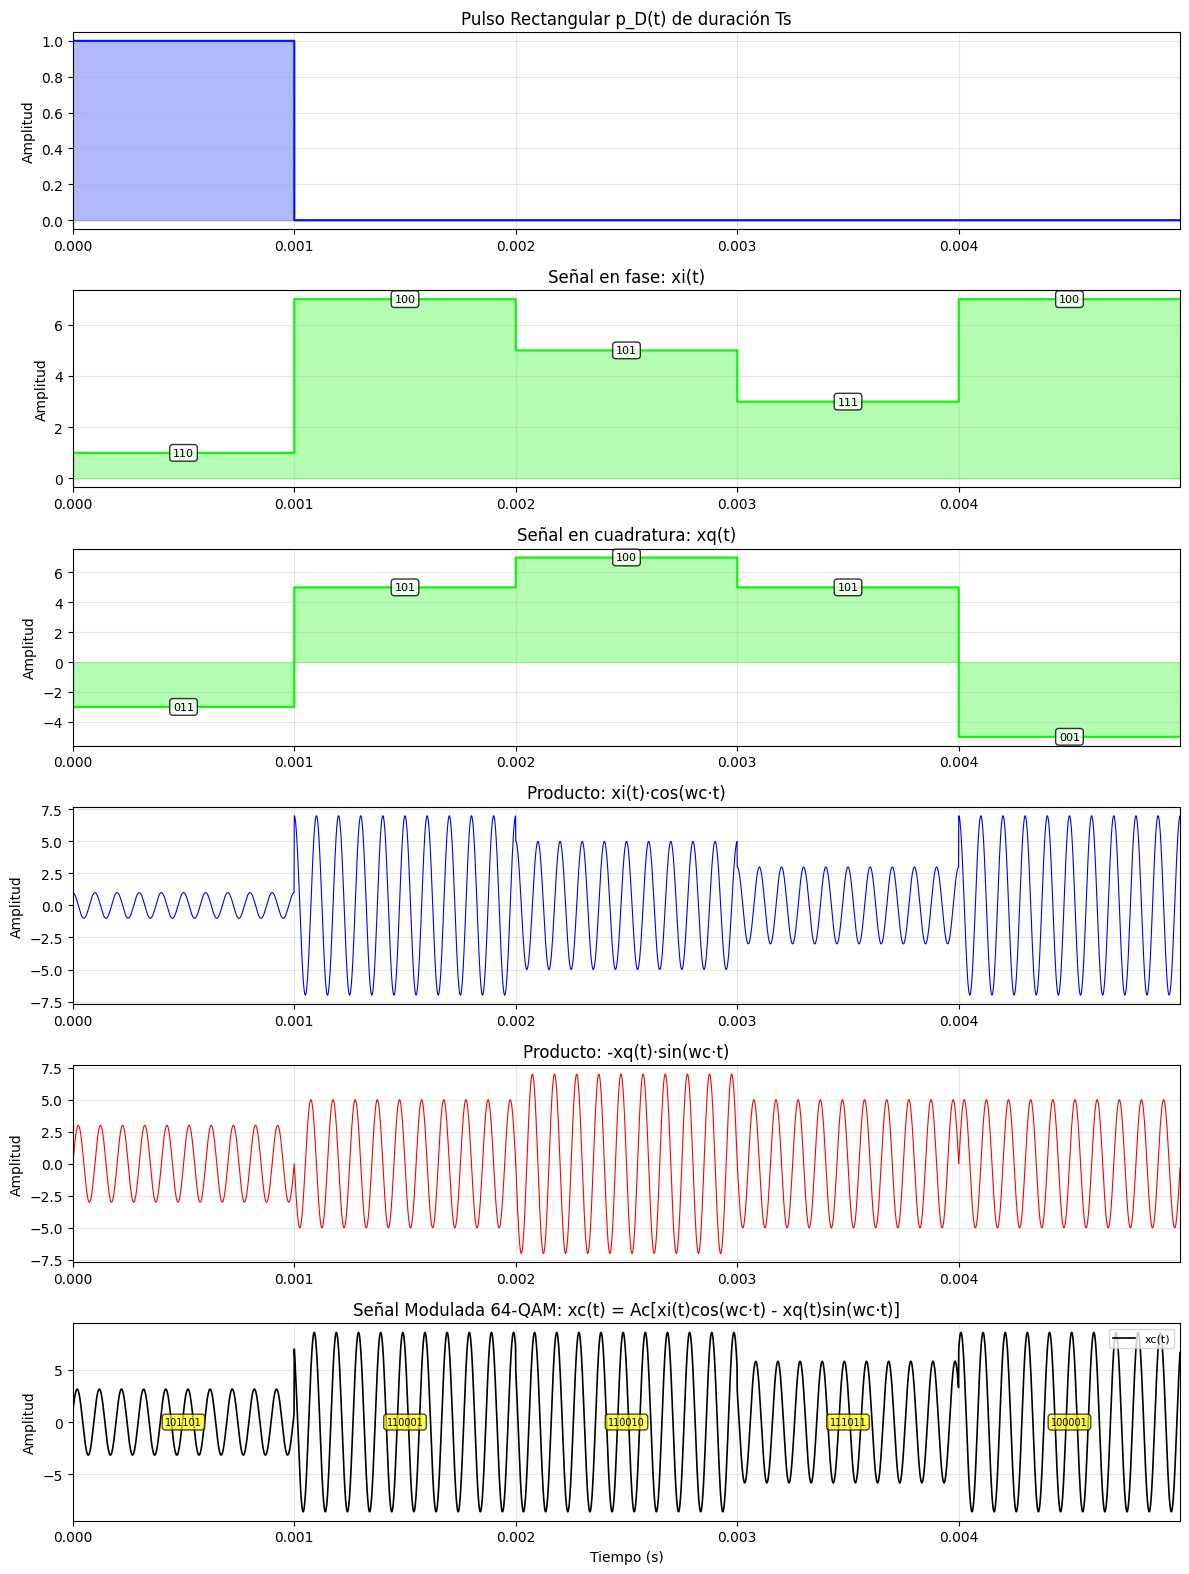

[1 0 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 1 1 1 0 1 1 1 0 0 0 0 1]


In [74]:
# Gráficos de las formas de onda
plt.figure(figsize=(12, 18))

# 1. Pulso rectangular
plt.subplot(7, 1, 1)
plt.step(t, pulso_rect, where='post', color='#0015FA', linewidth=1.5)
plt.fill_between(t, pulso_rect, color='#0015FA', alpha=0.3)
plt.title("Pulso Rectangular p_D(t) de duración Ts")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 2. Señal en fase xi(t) con códigos Gray
ax2 = plt.subplot(7, 1, 2)
plt.step(t, x_i, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_i, color='#09F700', alpha=0.3)
plt.title("Señal en fase: xi(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray centrados en el intervalo a la altura de la amplitud
for k in range(min(len(gray_I), num_simbolos)):
    if k < len(Ik):
        t_pos = (k + 0.5) * Ts  # Centrado en el medio del intervalo
        y_pos = Ik[k]  # Exactamente a la altura de la amplitud
        plt.text(t_pos, y_pos, gray_I[k], ha='center', va='center', 
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 3. Señal en cuadratura xq(t) con códigos Gray
ax3 = plt.subplot(7, 1, 3)
plt.step(t, x_q, where='post', color='#09F700', linewidth=1.5)
plt.fill_between(t, x_q, color='#09F700', alpha=0.3)
plt.title("Señal en cuadratura: xq(t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray centrados en el intervalo a la altura de la amplitud
for k in range(min(len(gray_Q), num_simbolos)):
    if k < len(Qk):
        t_pos = (k + 0.5) * Ts  # Centrado en el medio del intervalo
        y_pos = Qk[k]  # Exactamente a la altura de la amplitud
        plt.text(t_pos, y_pos, gray_Q[k], ha='center', va='center',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# 4. Producto xi(t)cos(wc·t)
plt.subplot(7, 1, 4)
plt.plot(t, xi_cos, color='blue', linewidth=0.8)
plt.title("Producto: xi(t)·cos(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 5. Producto -xq(t)sin(wc·t)
plt.subplot(7, 1, 5)
plt.plot(t, xq_sin, color='red', linewidth=0.8)
plt.title("Producto: -xq(t)·sin(wc·t)")
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])

# 6. Suma de productos (componentes de xc(t))
#plt.subplot(7, 1, 6)
#plt.plot(t, xi_cos, color='blue', linewidth=0.8, alpha=0.7, label='xi(t)·cos(wc·t)')
#plt.plot(t, xq_sin, color='red', linewidth=0.8, alpha=0.7, label='-xq(t)·sin(wc·t)')
#plt.title("Componentes de la señal modulada")
#plt.ylabel('Amplitud')
#plt.legend(loc='upper right', fontsize=8)
#plt.grid(True, alpha=0.3)
#lt.xlim([0, t[-1]])

# 7. Señal modulada xc(t)
ax7 = plt.subplot(7, 1, 6)
plt.plot(t, x_c, color='#000000', linewidth=1.2, label='xc(t)')
plt.title(f"Señal Modulada {M}-QAM: xc(t) = Ac[xi(t)cos(wc·t) - xq(t)sin(wc·t)]")
plt.ylabel('Amplitud')
plt.xlabel('Tiempo (s)')
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.xlim([0, t[-1]])
# Añadir códigos Gray completos centrados en el intervalo
# IMPORTANTE: Intercalar los bits de I y Q para reconstruir la secuencia original de entrada
for k in range(min(len(gray_I), num_simbolos)):
    t_pos = (k + 0.5) * Ts  # Centrado en el medio del intervalo
    y_pos = 0  # Centrado verticalmente (la señal modulada oscila alrededor de 0)
    
    # Intercalar bits: I[0]Q[0]I[1]Q[1]... para reconstruir la entrada original
    # El S/P toma bits alternados: pares→I, impares→Q
    # Entonces para reconstruir: intercalamos I[i] con Q[i]
    bits_intercalados = ''
    for i in range(len(gray_I[k])):
        bits_intercalados += gray_I[k][i] + gray_Q[k][i]
    
    plt.text(t_pos, y_pos, bits_intercalados, ha='center', va='center',
            fontsize=7, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()
print(secuencia)

# Variables estadísticas para el cálculo de la DEP

In [65]:
# Se obtiene la probabilidad de los símbolos
# Para I_k y Q_k en M-QAM, cada componente tiene μ = √M niveles

def get_prob_simbolo(bits, p0, p1):
    """Calcula la probabilidad de un código Gray dado p0 y p1"""
    prob = 1
    for b in bits:
        if b == '0':
            prob *= p0
        else:
            prob *= p1
    return prob

# Crear diccionarios de probabilidades para I_k y Q_k
# Generar código Gray para n bits (donde μ = 2^n)
gray_n = gray_code(n)

# Crear tabla de mapeo Gray: código → nivel para cada componente
tabla_mapeo_completa = {}
for i, code in enumerate(gray_n):
    nivel = 2*i - (mu - 1)
    tabla_mapeo_completa[code] = nivel

# Calcular probabilidades para I_k (y Q_k, ya que tienen la misma distribución)
P_Ik = {}
P_Qk = {}

for gray_code_str in gray_n:
    prob = get_prob_simbolo(gray_code_str, p0, p1)
    nivel = tabla_mapeo_completa[gray_code_str]
    P_Ik[nivel] = prob
    P_Qk[nivel] = prob

# Imprimir tabla de probabilidades
print("Tabla de probabilidades para I_k y Q_k:")
print(f"{'Gray':<10} {'Nivel (I_k o Q_k)':<20} {'p(nivel)':<10}")
print("-" * 45)
for gray_code_str in gray_n:
    prob = get_prob_simbolo(gray_code_str, p0, p1)
    nivel = tabla_mapeo_completa[gray_code_str]
    print(f"{gray_code_str:<10} {nivel:<20} {prob:<10.4f}")

Tabla de probabilidades para I_k y Q_k:
Gray       Nivel (I_k o Q_k)    p(nivel)  
---------------------------------------------
000        -7                   0.1106    
001        -5                   0.1198    
011        -3                   0.1298    
010        -1                   0.1198    
110        1                    0.1298    
111        3                    0.1406    
101        5                    0.1298    
100        7                    0.1198    


# Media de I_k
$$m_i = \overline{I_k} = \sum_{i=1}^{\mu} (I_k)_i \cdot p(I_k)_i$$

In [66]:
# Calcular la media de I_k
# m_i = Σ I_k * p(I_k)
def get_media(data):
    """Calcula el valor medio dado un diccionario {valor: probabilidad}"""
    media = 0
    for valor, prob in data.items():
        media += valor * prob
    return media

m_i = get_media(P_Ik)
print(f'Media de I_k: m_i = {m_i:.6f}')

Media de I_k: m_i = 0.156864


# Media de Q_k
$$m_q = \overline{Q_k} = \sum_{i=1}^{\mu} (Q_k)_i \cdot p(Q_k)_i$$

En QAM se cumple que $I_k \sim Q_k$, por lo tanto $m_i = m_q = m$

In [67]:
# Calcular la media de Q_k
# m_q = Σ Q_k * p(Q_k)
m_q = get_media(P_Qk)
print(f'Media de Q_k: m_q = {m_q:.6f}')

# Como I_k ~ Q_k, verificamos que m_i = m_q
m = m_i  # Se asigna m = m_i = m_q
print(f'\nEn QAM: m = m_i = m_q = {m:.6f}')

Media de Q_k: m_q = 0.156864

En QAM: m = m_i = m_q = 0.156864


# Varianza de I_k
$$\sigma_i^2 = \overline{I_k^2} - \overline{I_k}^2 = \sum_{i=1}^{\mu} (I_k^2)_i \cdot p(I_k)_i - m_i^2$$

In [68]:
# Calcular la varianza de I_k
# σ_i² = E[I_k²] - (E[I_k])² = Σ I_k² * p(I_k) - m_i²
def get_rms(data):
    """Calcula el valor cuadrático medio dado un diccionario {valor: probabilidad}"""
    rms = 0
    for valor, prob in data.items():
        rms += valor**2 * prob
    return rms

sigma_i2 = get_rms(P_Ik) - m_i**2
print(f'Varianza de I_k: σ_i² = {sigma_i2:.6f}')

Varianza de I_k: σ_i² = 20.188194


# Varianza de Q_k
$$\sigma_q^2 = \overline{Q_k^2} - \overline{Q_k}^2 = \sum_{i=1}^{\mu} (Q_k^2)_i \cdot p(Q_k)_i - m_q^2$$

En QAM se cumple que $I_k \sim Q_k$, por lo tanto $\sigma_i^2 = \sigma_q^2 = \sigma^2$

In [69]:
# Calcular la varianza de Q_k
# σ_q² = E[Q_k²] - (E[Q_k])² = Σ Q_k² * p(Q_k) - m_q²
sigma_q2 = get_rms(P_Qk) - m_q**2
print(f'Varianza de Q_k: σ_q² = {sigma_q2:.6f}')

# Como I_k ~ Q_k, verificamos que σ_i² = σ_q²
sigma2 = sigma_i2  # Se asigna σ² = σ_i² = σ_q²
print(f'\nEn QAM: σ² = σ_i² = σ_q² = {sigma2:.6f}')

Varianza de Q_k: σ_q² = 20.188194

En QAM: σ² = σ_i² = σ_q² = 20.188194


# Densidad Espectral de Potencia (DEP) M-QAM

## Ecuaciones de la DEP

**Densidad espectral de las señales de banda base:**

$$G_i(f) = \sigma_i^2 f_s |P_D(f)|^2 + (m_i f_s)^2 \sum_n |P_D(nf_s)|^2 \delta(f - nf_s)$$

$$G_q(f) = \sigma_q^2 f_s |P_D(f)|^2 + (m_q f_s)^2 \sum_n |P_D(nf_s)|^2 \delta(f - nf_s)$$

**Para pulso rectangular:**

$$|P_D(f)|^2 = \frac{1}{f_s^2} \text{sinc}^2\left(\frac{f}{f_s}\right)$$

**Sustituyendo:**

$$G_i(f) = \frac{\sigma_i^2}{f_s} \text{sinc}^2\left(\frac{f}{f_s}\right) + m_i^2 \delta(f)$$

$$G_q(f) = \frac{\sigma_q^2}{f_s} \text{sinc}^2\left(\frac{f}{f_s}\right) + m_q^2 \delta(f)$$

**En QAM, como $I_k \sim Q_k$, se cumple que $\sigma_i = \sigma_q = \sigma$ y $m_i = m_q = m$, por lo tanto:**

$$G_{lp}(f) = G_i(f) + G_q(f) = 2\left(\frac{\sigma^2}{f_s} \text{sinc}^2\left(\frac{f}{f_s}\right) + m^2 \delta(f)\right)$$

**Densidad espectral de la señal modulada:**

$$G_c(f) = \frac{A_c^2}{2} \left[\frac{\sigma^2}{f_s} \text{sinc}^2\left(\frac{f+f_c}{f_s}\right) + m^2 \delta(f+f_c) + \frac{\sigma^2}{f_s} \text{sinc}^2\left(\frac{f-f_c}{f_s}\right) + m^2 \delta(f-f_c)\right]$$

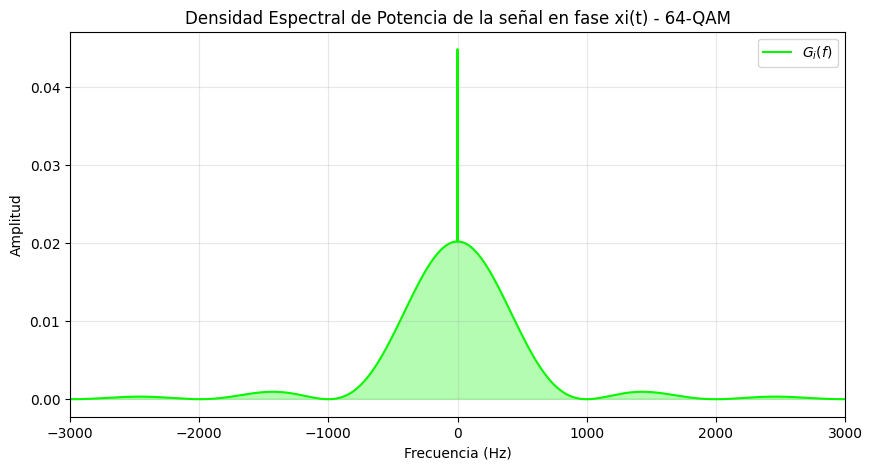

Componente continua máxima de G_i(f): 2.018819e-02
Componente discreta de G_i(f): 2.460631e-02


In [70]:
# Vector de frecuencias
f = np.linspace(-20000, 20000, 200000)

# Función delta de Dirac (aproximada)
def delta(arg):
    """Aproximación de la función delta de Dirac"""
    delta_signal = np.zeros_like(f)
    idx = np.argmin(np.abs(arg))
    delta_signal[idx] = 1
    return delta_signal

# Transformada de Fourier del pulso rectangular
# |P_D(f)|² = (1/fs²) * sinc²(f/fs)
P_D_squared = (1 / fs**2) * np.sinc(f / fs)**2

# Densidad espectral de potencia de la señal en fase
# G_i(f) = σ² / fs * sinc²(f/fs) + m² * δ(f)
G_i_continua = sigma2 / fs * np.sinc(f / fs)**2
G_i_discreta = m**2 * delta(f)
G_i = G_i_continua + G_i_discreta

# Gráfica de G_i(f)
plt.figure(figsize=(10, 5))
plt.plot(f, G_i, color='#09F700', label=r'$G_i(f)$')
plt.fill_between(f, G_i, color='#09F700', alpha=0.3)
plt.title(f"Densidad Espectral de Potencia de la señal en fase xi(t) - {M}-QAM")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-3*fs, 3*fs])
plt.show()

print(f"Componente continua máxima de G_i(f): {np.max(G_i_continua):.6e}")
print(f"Componente discreta de G_i(f): {m**2:.6e}")

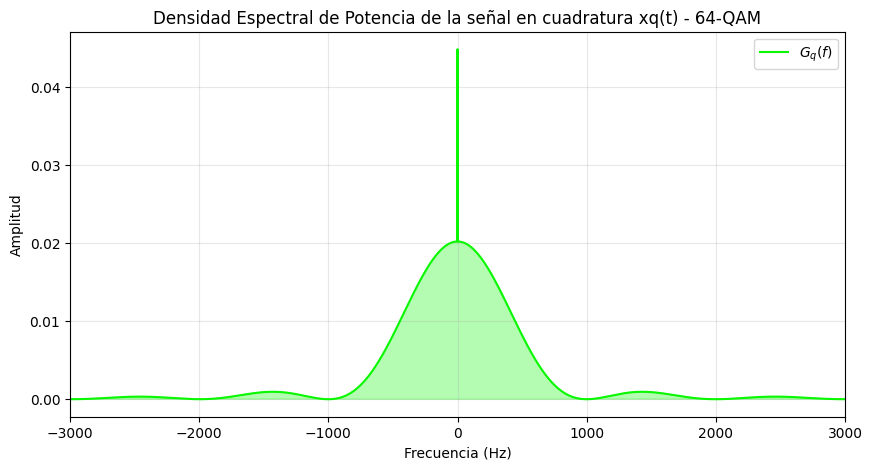

Componente continua máxima de G_q(f): 2.018819e-02
Componente discreta de G_q(f): 2.460631e-02


In [71]:
# Densidad espectral de potencia de la señal en cuadratura
# G_q(f) = σ² / fs * sinc²(f/fs) + m² * δ(f)
G_q_continua = sigma2 / fs * np.sinc(f / fs)**2
G_q_discreta = m**2 * delta(f)
G_q = G_q_continua + G_q_discreta

# Gráfica de G_q(f)
plt.figure(figsize=(10, 5))
plt.plot(f, G_q, color='#09F700', label=r'$G_q(f)$')
plt.fill_between(f, G_q, color='#09F700', alpha=0.3)
plt.title(f"Densidad Espectral de Potencia de la señal en cuadratura xq(t) - {M}-QAM")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-3*fs, 3*fs])
plt.show()

print(f"Componente continua máxima de G_q(f): {np.max(G_q_continua):.6e}")
print(f"Componente discreta de G_q(f): {m**2:.6e}")

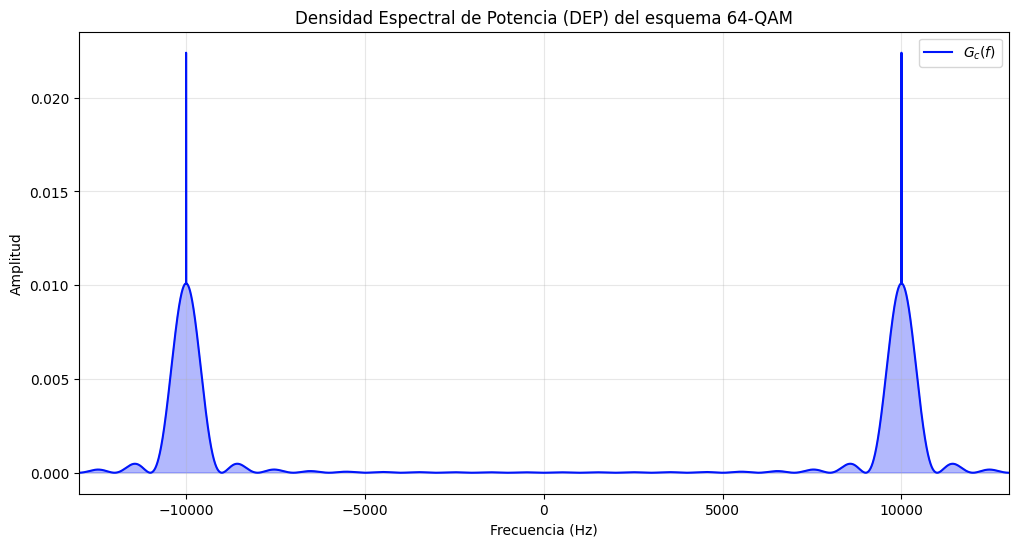


Resumen de la DEP:
Frecuencia de la portadora: fc = 10000 Hz
Frecuencia de símbolo: fs = 1000.0 Hz
Media: m = 0.156864
Varianza: σ² = 20.188194
Potencia máxima de G_c(f): 2.239725e-02


In [72]:
# Densidad espectral de potencia de la señal modulada
# G_c(f) = (A_c²/2) * [σ²/fs * sinc²((f+fc)/fs) + m² * δ(f+fc) + σ²/fs * sinc²((f-fc)/fs) + m² * δ(f-fc)]

# Calcular las componentes trasladadas en frecuencia
# Componente positiva (f - fc)
G_plus_continua = sigma2 / fs * np.sinc((f - fc) / fs)**2
G_plus_discreta = m**2 * delta(f - fc)

# Componente negativa (f + fc)
G_minus_continua = sigma2 / fs * np.sinc((f + fc) / fs)**2
G_minus_discreta = m**2 * delta(f + fc)

# G_c(f) total
G_c = (Ac**2 / 2) * (G_plus_continua + G_plus_discreta + G_minus_continua + G_minus_discreta)

# Gráfica de G_c(f)
plt.figure(figsize=(12, 6))
plt.plot(f, G_c, color='#0015FA', label=r'$G_c(f)$', linewidth=1.5)
plt.fill_between(f, G_c, color='#0015FA', alpha=0.3)
titulo = f"Densidad Espectral de Potencia (DEP) del esquema {M}-QAM"
plt.title(titulo)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([-fc - 3*fs, fc + 3*fs])
plt.show()

print(f"\nResumen de la DEP:")
print(f"Frecuencia de la portadora: fc = {fc} Hz")
print(f"Frecuencia de símbolo: fs = {fs} Hz")
print(f"Media: m = {m:.6f}")
print(f"Varianza: σ² = {sigma2:.6f}")
print(f"Potencia máxima de G_c(f): {np.max(G_c):.6e}")

# Diagrama de Constelación M-QAM

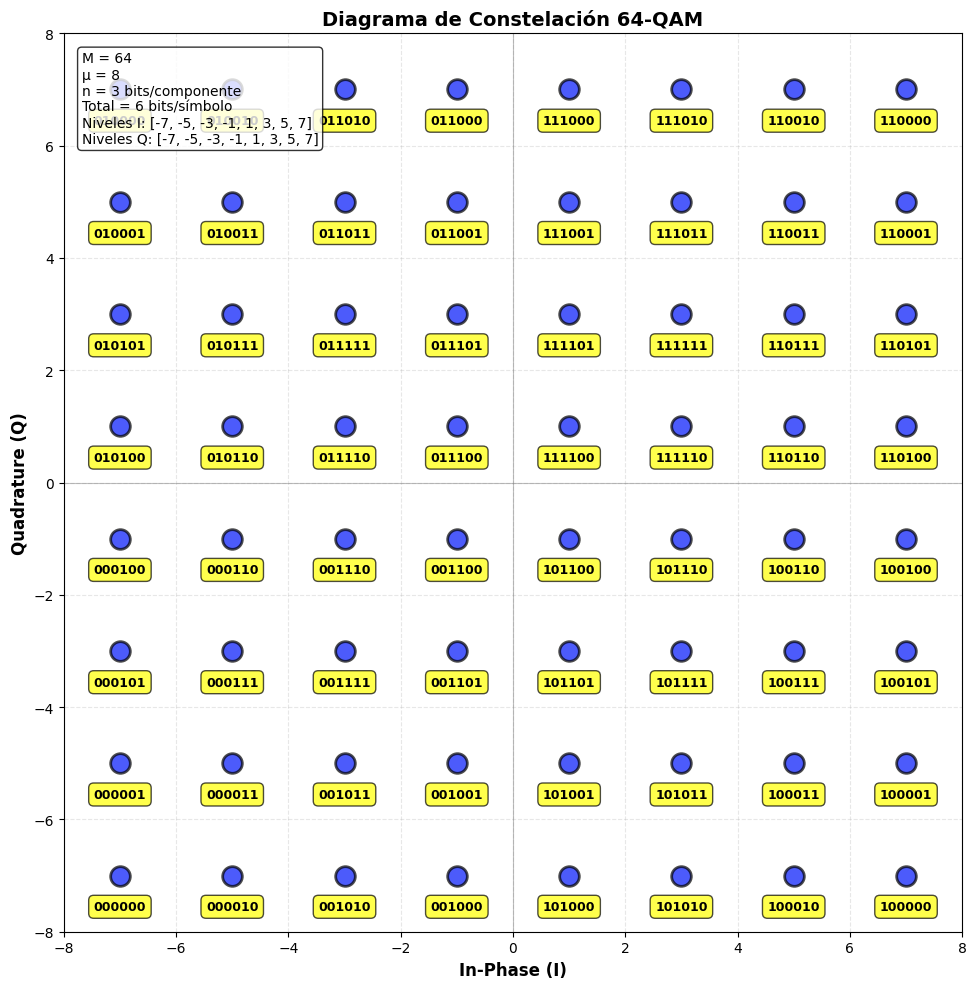

Diagrama de constelación 64-QAM generado
Número de puntos de señal: 64

Nota: Las etiquetas muestran los bits intercalados (entrada original)
Formato: I[0]Q[0]I[1]Q[1]... donde I=bits pares, Q=bits impares


In [73]:
# Generar todos los puntos de la constelación M-QAM
constelacion_I = []
constelacion_Q = []
labels_constelacion = []

# Para cada combinación de códigos Gray de I y Q
for gray_I_code in gray_n:
    for gray_Q_code in gray_n:
        # Obtener niveles I_k y Q_k
        nivel_I = tabla_mapeo_completa[gray_I_code]
        nivel_Q = tabla_mapeo_completa[gray_Q_code]
        
        constelacion_I.append(nivel_I)
        constelacion_Q.append(nivel_Q)
        
        # Intercalar bits de I y Q para reconstruir la secuencia original
        # S/P: pares→I, impares→Q, entonces intercalamos I[0]Q[0]I[1]Q[1]...
        bits_intercalados = ''
        for i in range(len(gray_I_code)):
            bits_intercalados += gray_I_code[i] + gray_Q_code[i]
        
        labels_constelacion.append(bits_intercalados)

# Crear diagrama de constelación
plt.figure(figsize=(10, 10))
plt.scatter(constelacion_I, constelacion_Q, s=200, c='#0015FA', marker='o', 
            edgecolors='black', linewidths=2, zorder=3, alpha=0.7)

# Agregar etiquetas de códigos (bits intercalados)
for i, (I, Q, label) in enumerate(zip(constelacion_I, constelacion_Q, labels_constelacion)):
    plt.annotate(label, (I, Q), xytext=(0, -25), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='yellow', alpha=0.7))

# Configuración de ejes
max_nivel = mu - 1
plt.axhline(y=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlabel('In-Phase (I)', fontsize=12, fontweight='bold')
plt.ylabel('Quadrature (Q)', fontsize=12, fontweight='bold')
plt.title(f'Diagrama de Constelación {M}-QAM', fontsize=14, fontweight='bold')
plt.xlim([-max_nivel-1, max_nivel+1])
plt.ylim([-max_nivel-1, max_nivel+1])
plt.gca().set_aspect('equal', adjustable='box')

# Agregar información adicional
info_text = f'M = {M}\nμ = {mu}\nn = {n} bits/componente\nTotal = {n_total} bits/símbolo\nNiveles I: {list(sorted(set(constelacion_I)))}\nNiveles Q: {list(sorted(set(constelacion_Q)))}'
plt.text(0.02, 0.98, info_text, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Diagrama de constelación {M}-QAM generado")
print(f"Número de puntos de señal: {len(constelacion_I)}")
print(f"\nNota: Las etiquetas muestran los bits intercalados (entrada original)")
print(f"Formato: I[0]Q[0]I[1]Q[1]... donde I=bits pares, Q=bits impares")